In [1]:
# Numerical libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Train test split
from sklearn.model_selection import train_test_split

# SVM model
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
from google.colab import files
df = files.upload()

#Read exel file
df = pd.read_csv('SVm-Dataset.csv')
# Display first  rows
df.head()

Saving SVm-Dataset.csv to SVm-Dataset (1).csv


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


In [4]:
# Shape of dataset
print(df.shape)

# Column names
print(df.columns)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

(45000, 15)
Index(['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA',
       'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
       'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications',
       'Backlogs', 'Placement_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student_ID            45000 non-null  int64  
 1   Age                   45000 non-null  int64  
 2   Gender                45000 non-null  object 
 3   Degree                45000 non-null  object 
 4   Branch                45000 non-null  object 
 5   CGPA                  45000 non-null  float64
 6   Internships           45000 non-null  int64  
 7   Projects              45000 non-null  int64  
 8   Coding_Skills         45000 non-null  int64  
 9   Communication_Skills  45000 non-null  in

In [5]:
# Check null values
print(df.isnull().sum())

Student_ID              0
Age                     0
Gender                  0
Degree                  0
Branch                  0
CGPA                    0
Internships             0
Projects                0
Coding_Skills           0
Communication_Skills    0
Aptitude_Test_Score     0
Soft_Skills_Rating      0
Certifications          0
Backlogs                0
Placement_Status        0
dtype: int64


In [6]:
df.columns = df.columns.str.strip()

In [7]:
print(df.columns)

Index(['Student_ID', 'Age', 'Gender', 'Degree', 'Branch', 'CGPA',
       'Internships', 'Projects', 'Coding_Skills', 'Communication_Skills',
       'Aptitude_Test_Score', 'Soft_Skills_Rating', 'Certifications',
       'Backlogs', 'Placement_Status'],
      dtype='object')


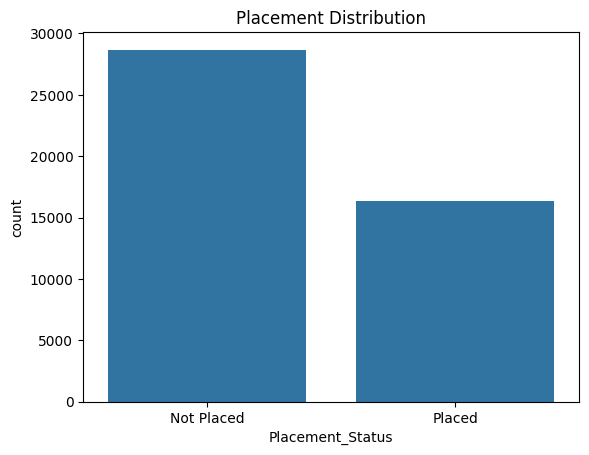

In [8]:
sns.countplot(x='Placement_Status', data=df)

plt.title("Placement Distribution")

plt.show()

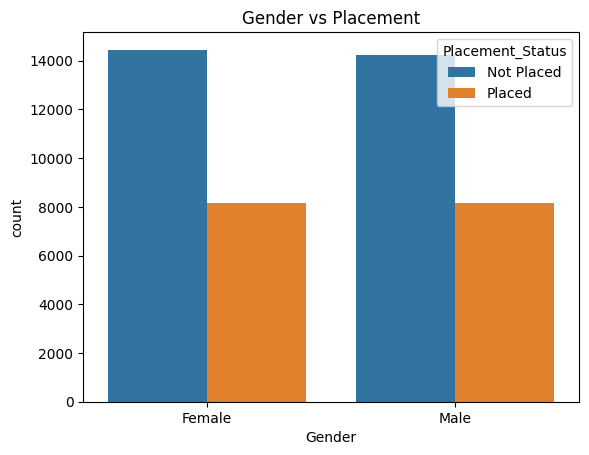

In [9]:
sns.countplot(x='Gender',
              hue='Placement_Status',
              data=df)

plt.title("Gender vs Placement")

plt.show()

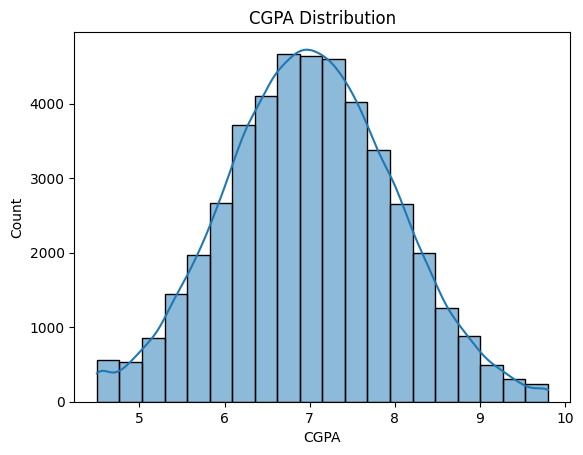

In [10]:
sns.histplot(df['CGPA'],
             bins=20,
             kde=True)

plt.title("CGPA Distribution")

plt.show()

In [11]:
Categorical_col = df.select_dtypes(include = 'object').columns
Categorical_col

Index(['Gender', 'Degree', 'Branch', 'Placement_Status'], dtype='object')

In [12]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

df['Degree'] = le.fit_transform(df['Degree'])

df['Branch'] = le.fit_transform(df['Branch'])

df['Placement_Status'] = le.fit_transform(df['Placement_Status'])

In [13]:
X = df.drop('Placement_Status', axis=1)
y = df['Placement_Status']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

svm_model = SVC(
    kernel='linear',
    C=1
)

svm_model.fit(X_train, y_train)

SVC(C=1, kernel='linear')

In [15]:
y_pred = svm_model.predict(X_test)

print(y_pred)



[1 0 1 ... 0 0 0]


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)



Accuracy : 0.8668888888888889


[[5108  601]
 [ 597 2694]]


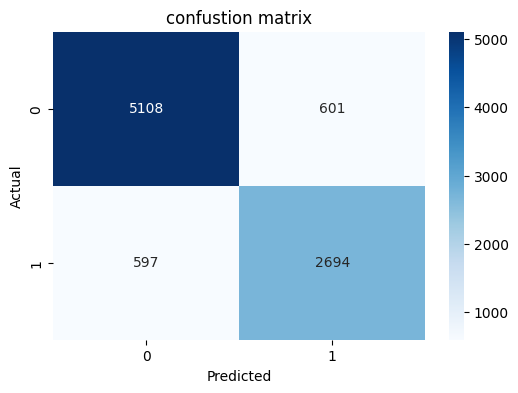

In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("confustion matrix")
plt.show()

In [19]:
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5709
           1       0.82      0.82      0.82      3291

    accuracy                           0.87      9000
   macro avg       0.86      0.86      0.86      9000
weighted avg       0.87      0.87      0.87      9000



In [20]:
svm_rbf = SVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)

svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

RBF Accuracy: 0.9805555555555555


In [21]:
svm_rbf.fit(X_train, y_train)

rbf_pred = svm_rbf.predict(X_test)

print("RBF Accuracy:",
      accuracy_score(y_test, rbf_pred))

svm_poly = SVC(
    kernel='poly',
    degree=3
)

svm_poly.fit(X_train, y_train)

poly_pred = svm_poly.predict(X_test)

print("Polynomial Accuracy:",
      accuracy_score(y_test, poly_pred))

RBF Accuracy: 0.9805555555555555
Polynomial Accuracy: 0.9236666666666666


In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

In [24]:
grid = GridSearchCV(
    SVC(),
    param_grid,
    refit=True,
    verbose=2
)

In [25]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 2.0min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.9min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.9min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.8min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 1.8min
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  16.8s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  19.4s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  17.2s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  17.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=  18.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  16.8s
[CV] END .......................C=0.1, gamma=0.1

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01],
                         'kernel': ['rbf', 'linear']},
             verbose=2)

In [26]:
print(grid.best_params_)

{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [27]:
print(grid.best_estimator_)

SVC(C=10, gamma=0.1)


In [28]:
best_model = grid.best_estimator_

final_prediction = best_model.predict(X_test)

print("Final Accuracy:",
      accuracy_score(y_test, final_prediction))

Final Accuracy: 0.991
